In [ ]:
import pandas as pd

df = pd.read_csv("/content/heart_failure_clinical_records_dataset.csv")

print("First 5 rows:")
print(df.head())

First 5 rows:
    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  75.0        0                       582         0                 20   
1  55.0        0                      7861         0                 38   
2  65.0        0                       146         0                 20   
3  50.0        1                       111         0                 20   
4  65.0        1                       160         1                 20   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
0                    1  265000.00               1.9           130    1   
1                    0  263358.03               1.1           136    1   
2                    0  162000.00               1.3           129    1   
3                    0  210000.00               1.9           137    1   
4                    0  327000.00               2.7           116    0   

   smoking  time  DEATH_EVENT  
0        0     4            1  
1        0     6          

In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 299
Number of columns: 13


In [ ]:
print(df.dtypes)

age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [ ]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


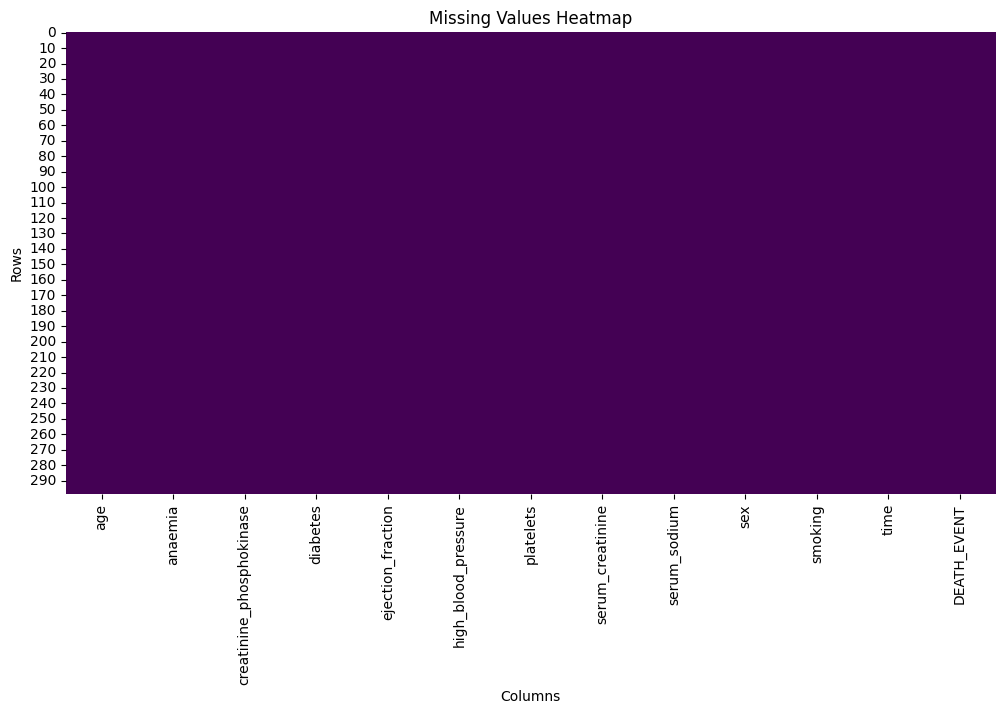

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Values Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")

plt.show()

In [ ]:
df.isnull()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,False,False,False,False,False,False,False,False,False,False,False,False,False
295,False,False,False,False,False,False,False,False,False,False,False,False,False
296,False,False,False,False,False,False,False,False,False,False,False,False,False
297,False,False,False,False,False,False,False,False,False,False,False,False,False


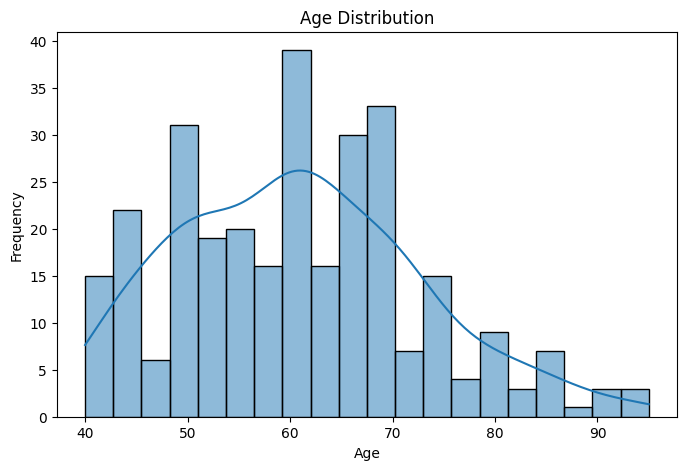

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(df["age"], bins=20, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

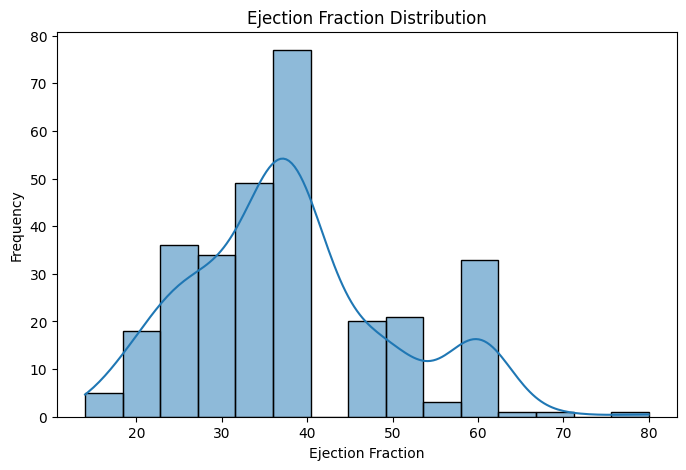

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(df["ejection_fraction"], bins=15, kde=True)

plt.title("Ejection Fraction Distribution")
plt.xlabel("Ejection Fraction")
plt.ylabel("Frequency")

plt.show()

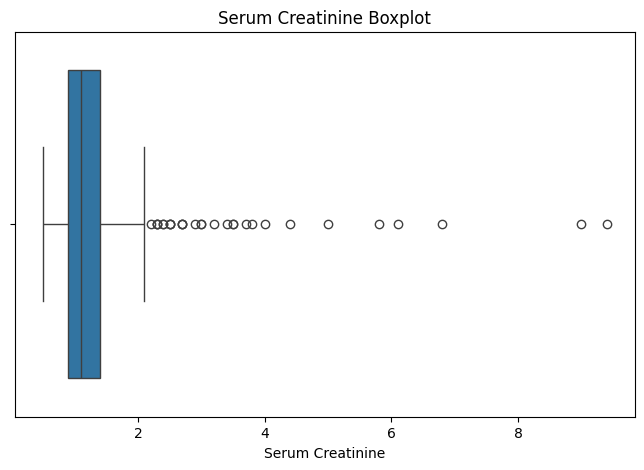

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["serum_creatinine"])

plt.title("Serum Creatinine Boxplot")
plt.xlabel("Serum Creatinine")

plt.show()

In [60]:
df_clean = df.copy()

df_clean.loc[5, "age"] = None
df_clean.loc[10, "serum_creatinine"] = None
df_clean.loc[15, "smoking"] = None
df_clean.loc[20, "ejection_fraction"] = None

print(df_clean.isnull().sum())

age                         1
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           1
high_blood_pressure         0
platelets                   0
serum_creatinine            1
serum_sodium                0
sex                         0
smoking                     1
time                        0
DEATH_EVENT                 0
dtype: int64


In [61]:
numerical_columns = [
    "age",
    "creatinine_phosphokinase",
    "ejection_fraction",
    "platelets",
    "serum_creatinine",
    "serum_sodium",
    "time"
]

for column in numerical_columns:
    df_clean[column] = df_clean[column].fillna(
        df_clean[column].median()
    )

In [62]:
categorical_columns = [
    "anaemia",
    "diabetes",
    "high_blood_pressure",
    "sex",
    "smoking"
]

for column in categorical_columns:
    df_clean[column] = df_clean[column].fillna(
        df_clean[column].mode()[0]
    )

In [63]:

df_no_outliers = df_clean.copy()

for column in numerical_columns:

    Q1 = df_no_outliers[column].quantile(0.25)
    Q3 = df_no_outliers[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df_no_outliers = df_no_outliers[
        (df_no_outliers[column] >= lower_limit) &
        (df_no_outliers[column] <= upper_limit)
    ]

print("Original rows:", len(df_clean))
print("Rows after outlier removal:", len(df_no_outliers))

Original rows: 299
Rows after outlier removal: 225


In [ ]:
print(df_clean["age"].min())
print(df_clean["age"].max())

40.0
95.0


In [64]:
invalid_age = df_clean[df_clean["age"] < 0]

print(invalid_age)

Empty DataFrame
Columns: [age, anaemia, creatinine_phosphokinase, diabetes, ejection_fraction, high_blood_pressure, platelets, serum_creatinine, serum_sodium, sex, smoking, time, DEATH_EVENT]
Index: []


In [65]:
df_clean = df_clean[df_clean["age"] >= 0]

In [66]:
invalid_ef = df_clean[
    (df_clean["ejection_fraction"] < 0) |
    (df_clean["ejection_fraction"] > 100)
]

print(invalid_ef)

Empty DataFrame
Columns: [age, anaemia, creatinine_phosphokinase, diabetes, ejection_fraction, high_blood_pressure, platelets, serum_creatinine, serum_sodium, sex, smoking, time, DEATH_EVENT]
Index: []


In [67]:
df_clean = df_clean[
    (df_clean["ejection_fraction"] >= 0) &
    (df_clean["ejection_fraction"] <= 100)
]

In [68]:
invalid_creatinine = df_clean[
    df_clean["serum_creatinine"] <= 0
]

print(invalid_creatinine)

Empty DataFrame
Columns: [age, anaemia, creatinine_phosphokinase, diabetes, ejection_fraction, high_blood_pressure, platelets, serum_creatinine, serum_sodium, sex, smoking, time, DEATH_EVENT]
Index: []


In [69]:
df_clean = df_clean[
    df_clean["serum_creatinine"] > 0
]

In [70]:
def age_group(age):

    if age < 40:
        return "Young"

    elif age <= 60:
        return "Middle"

    else:
        return "Old"


df_clean["age_group"] = df_clean["age"].apply(age_group)

print(df_clean[["age", "age_group"]].head(10))

    age age_group
0  75.0       Old
1  55.0    Middle
2  65.0       Old
3  50.0    Middle
4  65.0       Old
5  60.0    Middle
6  75.0       Old
7  60.0    Middle
8  65.0       Old
9  80.0       Old


In [71]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_clean[[
    "ef_normalized",
    "creatinine_normalized"
]] = scaler.fit_transform(
    df_clean[
        ["ejection_fraction", "serum_creatinine"]
    ]
)

In [72]:
df_clean["risk_score"] = (
    df_clean["ef_normalized"] *
    df_clean["creatinine_normalized"]
)

In [73]:
print(
    df_clean[
        [
            "ejection_fraction",
            "serum_creatinine",
            "risk_score"
        ]
    ].head()
)

   ejection_fraction  serum_creatinine  risk_score
0               20.0               1.9    0.014300
1               38.0               1.1    0.024515
2               20.0               1.3    0.008172
3               20.0               1.9    0.014300
4               20.0               2.7    0.022472


In [75]:
df_encoded = pd.get_dummies(
    df_clean,
    columns=["age_group"],
    dtype=int
)

print(df_encoded.head())

    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  75.0        0                       582         0               20.0   
1  55.0        0                      7861         0               38.0   
2  65.0        0                       146         0               20.0   
3  50.0        1                       111         0               20.0   
4  65.0        1                       160         1               20.0   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
0                    1  265000.00               1.9           130    1   
1                    0  263358.03               1.1           136    1   
2                    0  162000.00               1.3           129    1   
3                    0  210000.00               1.9           137    1   
4                    0  327000.00               2.7           116    0   

   smoking  time  DEATH_EVENT  ef_normalized  creatinine_normalized  \
0      0.0     4            1    

In [76]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

features_to_scale = [
    "age",
    "creatinine_phosphokinase",
    "ejection_fraction",
    "platelets",
    "serum_creatinine",
    "serum_sodium",
    "time"
]

df_encoded[features_to_scale] = scaler.fit_transform(
    df_encoded[features_to_scale]
)

print(df_encoded[features_to_scale].head())

        age  creatinine_phosphokinase  ejection_fraction  platelets  \
0  0.636364                  0.071319           0.090909   0.290823   
1  0.272727                  1.000000           0.363636   0.288833   
2  0.454545                  0.015693           0.090909   0.165960   
3  0.181818                  0.011227           0.090909   0.224148   
4  0.454545                  0.017479           0.090909   0.365984   

   serum_creatinine  serum_sodium      time  
0          0.157303      0.485714  0.000000  
1          0.067416      0.657143  0.007117  
2          0.089888      0.457143  0.010676  
3          0.157303      0.685714  0.010676  
4          0.247191      0.085714  0.014235  


In [77]:
print(df_encoded[features_to_scale].min())
print(df_encoded[features_to_scale].max())

age                         0.0
creatinine_phosphokinase    0.0
ejection_fraction           0.0
platelets                   0.0
serum_creatinine            0.0
serum_sodium                0.0
time                        0.0
dtype: float64
age                         1.0
creatinine_phosphokinase    1.0
ejection_fraction           1.0
platelets                   1.0
serum_creatinine            1.0
serum_sodium                1.0
time                        1.0
dtype: float64


In [78]:
before_stats = df[numerical_columns].agg(
    ["mean", "median", "std"]
)

print("Statistics BEFORE cleaning:")
print(before_stats)

Statistics BEFORE cleaning:
              age  creatinine_phosphokinase  ejection_fraction      platelets  \
mean    60.833893                581.839465          38.083612  263358.029264   
median  60.000000                250.000000          38.000000  262000.000000   
std     11.894809                970.287881          11.834841   97804.236869   

        serum_creatinine  serum_sodium        time  
mean             1.39388    136.625418  130.260870  
median           1.10000    137.000000  115.000000  
std              1.03451      4.412477   77.614208  


In [79]:
after_stats = df_clean[numerical_columns].agg(
    ["mean", "median", "std"]
)

print("Statistics AFTER cleaning:")
print(after_stats)

Statistics AFTER cleaning:
              age  creatinine_phosphokinase  ejection_fraction      platelets  \
mean    60.733559                581.839465          38.127090  263358.029264   
median  60.000000                250.000000          38.000000  262000.000000   
std     11.773876                970.287881          11.810468   97804.236869   

        serum_creatinine  serum_sodium        time  
mean            1.384181    136.625418  130.260870  
median          1.100000    137.000000  115.000000  
std             1.023531      4.412477   77.614208  


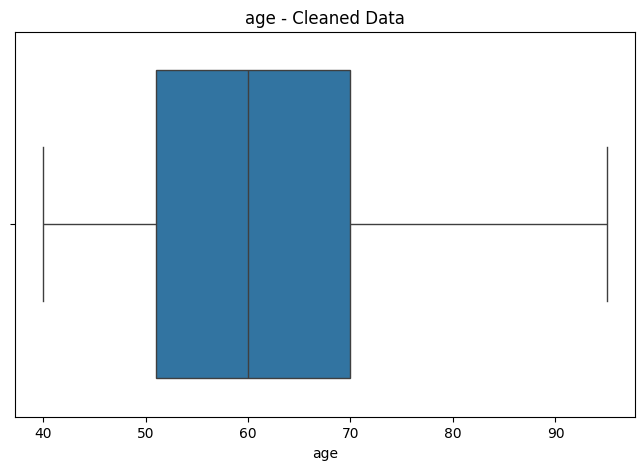

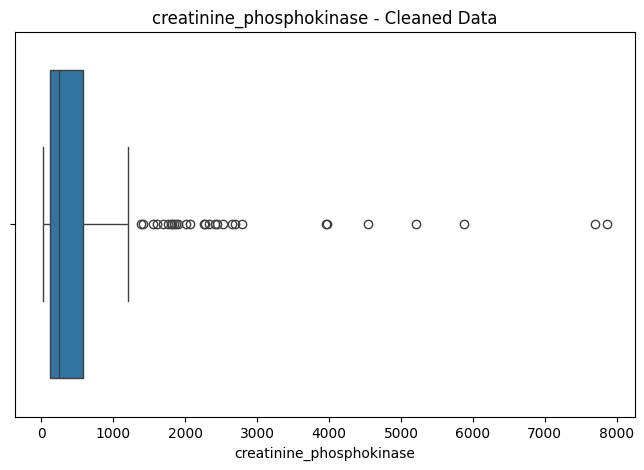

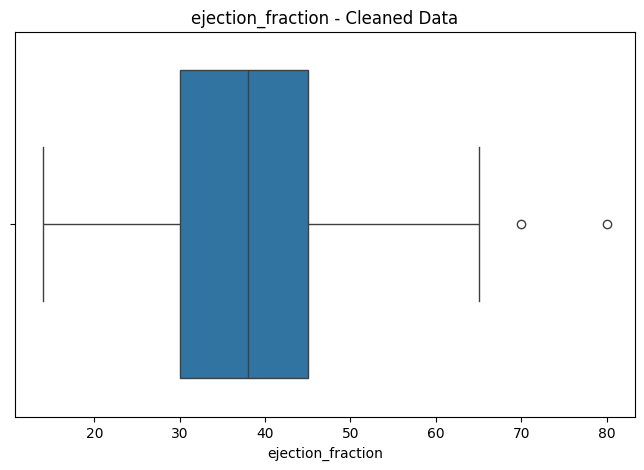

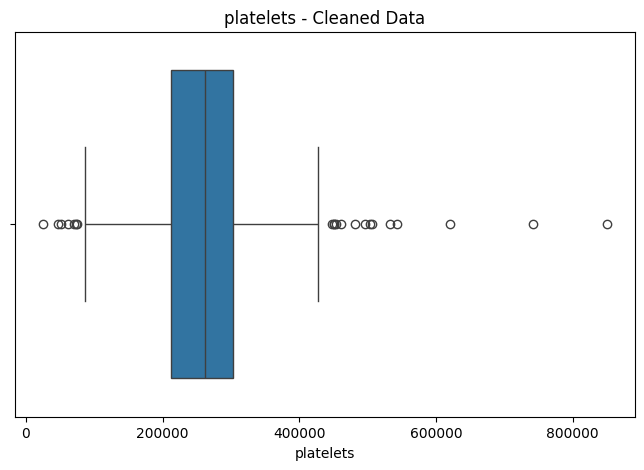

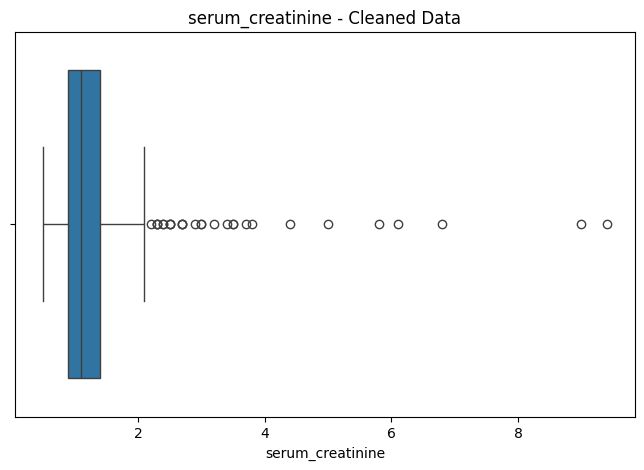

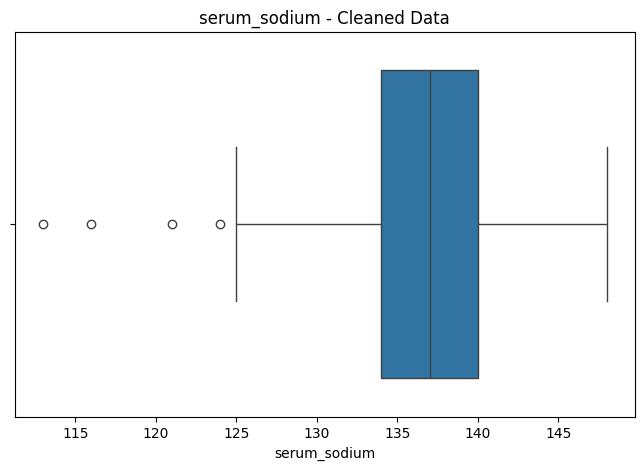

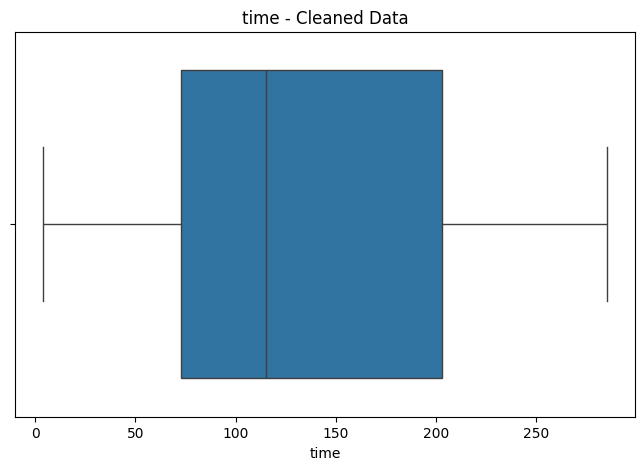

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns


for column in features_to_scale:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=df_clean[column])

    plt.title(f"{column} - Cleaned Data")
    plt.xlabel(column)

    plt.show()

In [81]:
print("Missing values in each column:")
print(df_clean.isnull().sum())

total_missing = df_clean.isnull().sum().sum()

Missing values in each column:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
age_group                   0
ef_normalized               0
creatinine_normalized       0
risk_score                  0
dtype: int64
